# Génération et Exploration du Dataset Synthétisé
## Basé sur : FAO, IITA, IRAD, CIRAD

**Objectif :** Générer un dataset agronomique scientifiquement fondé pour l'Afrique sub-saharienne (Cameroun), avec :
- Unités N, P, K en **mg/kg** (ppm)
- Uniquement les cultures **référencées** dans les 4 sources
- 15 cultures × 500 échantillons = **7 500 lignes**

**Références :**
- [1] FAO. *Crop Production Guidelines and Soil Management in Tropical Regions*.
- [2] IITA. *Crop and Soil Fertility Management Practices in Sub-Saharan Africa*.
- [3] IRAD. *Fiches techniques des cultures vivrières et de rente au Cameroun*.
- [4] CIRAD. *Agronomic Practices in Tropical Agriculture*.

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sys.path.insert(0, str(Path('.').resolve()))
from generate_research_dataset import generate_dataset, CROP_PARAMS

sns.set_theme(style='whitegrid', palette='tab20')
plt.rcParams['figure.dpi'] = 120
print('Librairies chargées.')

Librairies chargées.


## 1. Génération du Dataset

In [2]:
df = generate_dataset(samples_per_crop=500)

print(f'Forme du dataset : {df.shape}')
print(f'Cultures ({df["label"].nunique()}) :')
for c in sorted(df['label'].unique()):
    print(f'  - {c}')
df.head()

Forme du dataset : (7500, 8)
Cultures (15) :
  - banane_plantain
  - cacao
  - cafe_arabica
  - cafe_robusta
  - haricot
  - igname
  - mais
  - manioc
  - mil
  - niebe
  - palmier_a_huile
  - riz
  - soja
  - sorgho
  - taro


,N,P,K,temperature,humidity,ph,rainfall,label
0,82.47,34.01,41.96,27.99,73.12,5.31,1275.51,riz
1,111.97,27.02,41.24,22.21,89.40,6.66,1476.04,riz
2,70.91,18.67,29.13,27.25,78.64,5.58,1995.41,riz
3,68.37,20.84,30.99,26.56,85.70,5.40,1868.50,riz
4,95.54,15.93,38.23,23.71,71.30,6.90,2455.32,riz


## 2. Statistiques Descriptives

In [3]:
print('=== Statistiques globales ===')
df.describe().round(2)

=== Statistiques globales ===


,N,P,K,temperature,humidity,ph,rainfall
count,7500.00,7500.00,7500.00,7500.00,7500.00,7500.00,7500.00
mean,86.04,33.06,84.64,27.21,68.26,6.23,1527.11
std,39.73,13.89,55.33,4.57,15.12,0.67,875.99
min,15.00,5.15,10.04,15.01,25.00,4.50,200.94
25%,53.27,22.79,39.32,24.18,59.76,5.75,754.18
50%,84.35,31.17,72.63,27.22,71.16,6.19,1445.00
75%,113.72,41.79,116.04,30.33,79.37,6.66,2162.96
max,199.79,79.73,279.69,39.97,95.00,8.50,3998.10


In [4]:
print('=== Moyennes par culture (N, P, K en mg/kg) ===')
summary = df.groupby('label')[['N', 'P', 'K', 'ph', 'temperature', 'humidity', 'rainfall']].mean().round(1)
summary

=== Moyennes par culture (N, P, K en mg/kg) ===


,N,P,K,ph,temperature,humidity,rainfall
label,,,,,,,
banane_plantain,149.2,54.9,203.3,6.5,28.5,80.3,2667.6
cacao,98.7,47.4,86.3,6.3,24.9,79.9,2239.3
cafe_arabica,109.5,32.2,85.5,6.0,19.5,64.9,1997.8
cafe_robusta,120.7,37.9,95.0,5.7,26.0,72.1,1839.5
haricot,40.2,27.5,40.5,6.3,23.0,62.8,649.4
igname,93.7,39.6,129.7,6.3,28.9,73.1,1418.5
mais,114.5,35.5,54.6,6.4,24.9,67.2,900.3
manioc,84.0,30.4,141.5,6.0,29.3,72.1,1403.9
mil,44.8,15.2,25.3,7.0,32.4,39.2,453.3


## 3. Visualisation des Distributions

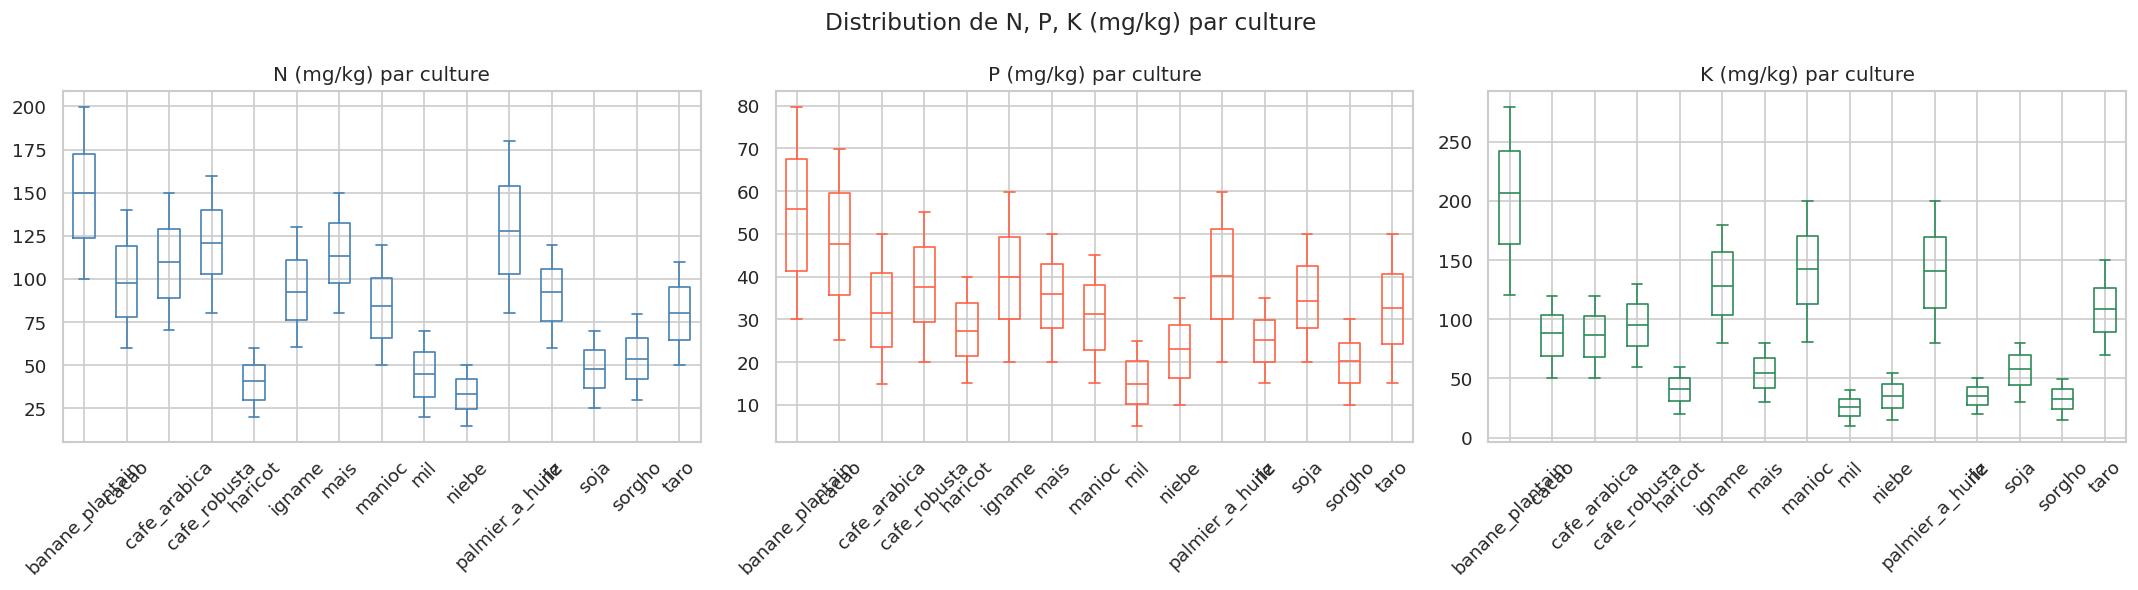

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col, color in zip(axes, ['N', 'P', 'K'], ['steelblue', 'tomato', 'seagreen']):
    df.boxplot(column=col, by='label', ax=ax, color=color, sym='.')
    ax.set_title(f'{col} (mg/kg) par culture')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    plt.sca(ax)
    plt.xlabel('')
fig.suptitle('Distribution de N, P, K (mg/kg) par culture', fontsize=14)
plt.tight_layout()
plt.show()

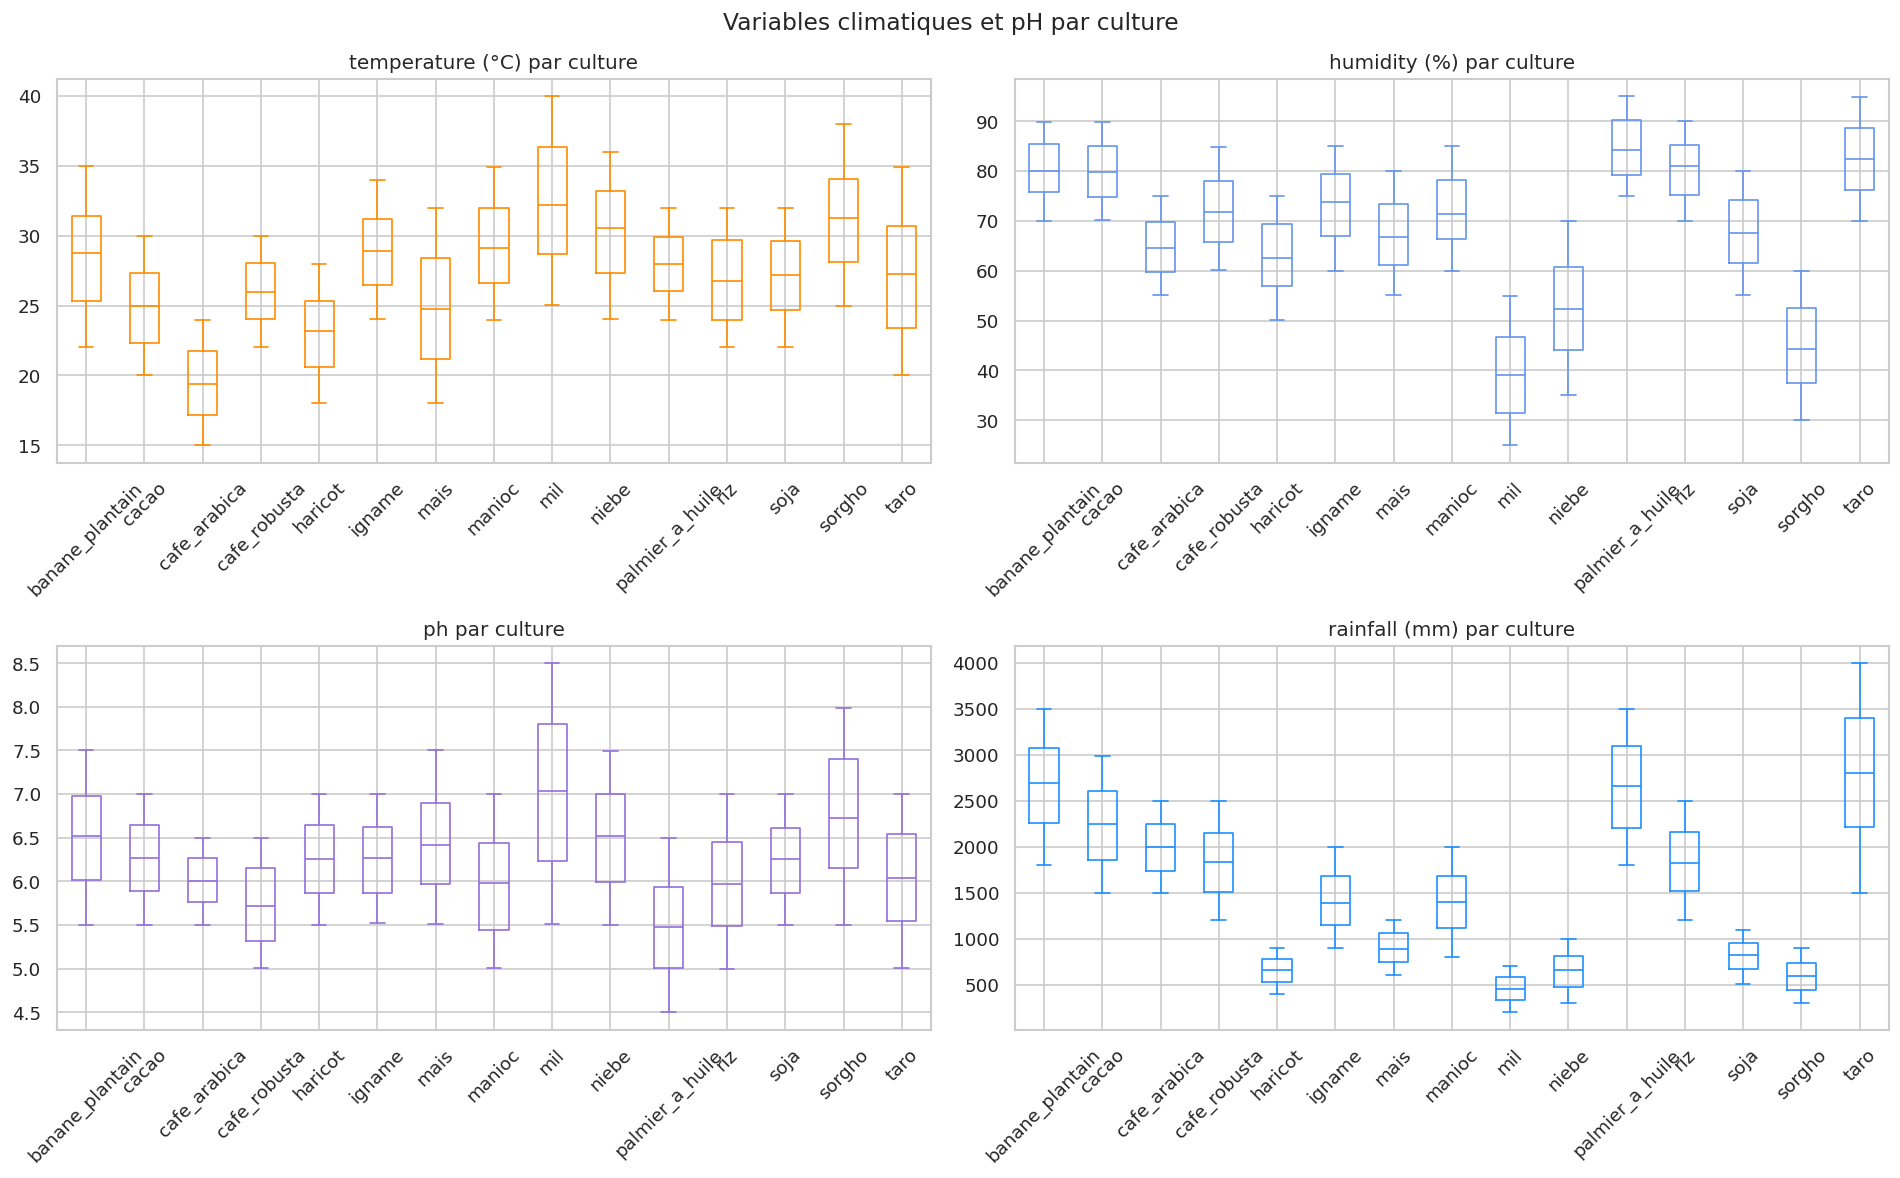

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
climate_vars = [
    ('temperature', '°C', 'darkorange'),
    ('humidity',    '%',  'cornflowerblue'),
    ('ph',          '',   'mediumpurple'),
    ('rainfall',    'mm', 'dodgerblue'),
]
for ax, (col, unit, color) in zip(axes.flatten(), climate_vars):
    df.boxplot(column=col, by='label', ax=ax, color=color, sym='.')
    ax.set_title(f'{col} ({unit}) par culture' if unit else f'{col} par culture')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    plt.sca(ax)
    plt.xlabel('')
fig.suptitle('Variables climatiques et pH par culture', fontsize=14)
plt.tight_layout()
plt.show()

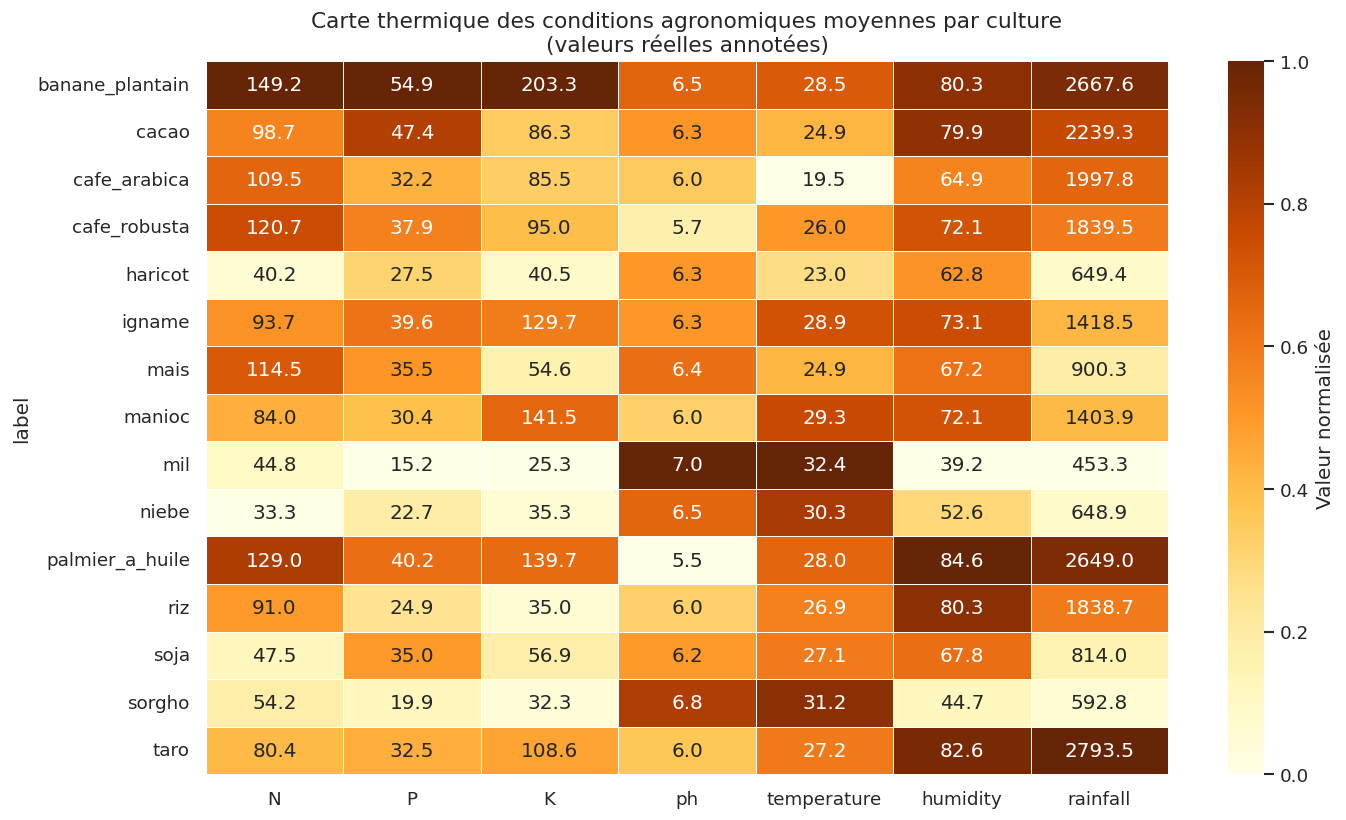

In [7]:
means = df.groupby('label')[['N', 'P', 'K', 'ph', 'temperature', 'humidity', 'rainfall']].mean()
means_norm = (means - means.min()) / (means.max() - means.min())

plt.figure(figsize=(12, 7))
sns.heatmap(means_norm, annot=means.round(1), fmt='.1f', cmap='YlOrBr',
            linewidths=0.5, cbar_kws={'label': 'Valeur normalisée'})
plt.title('Carte thermique des conditions agronomiques moyennes par culture\n(valeurs réelles annotées)', fontsize=13)
plt.tight_layout()
plt.show()

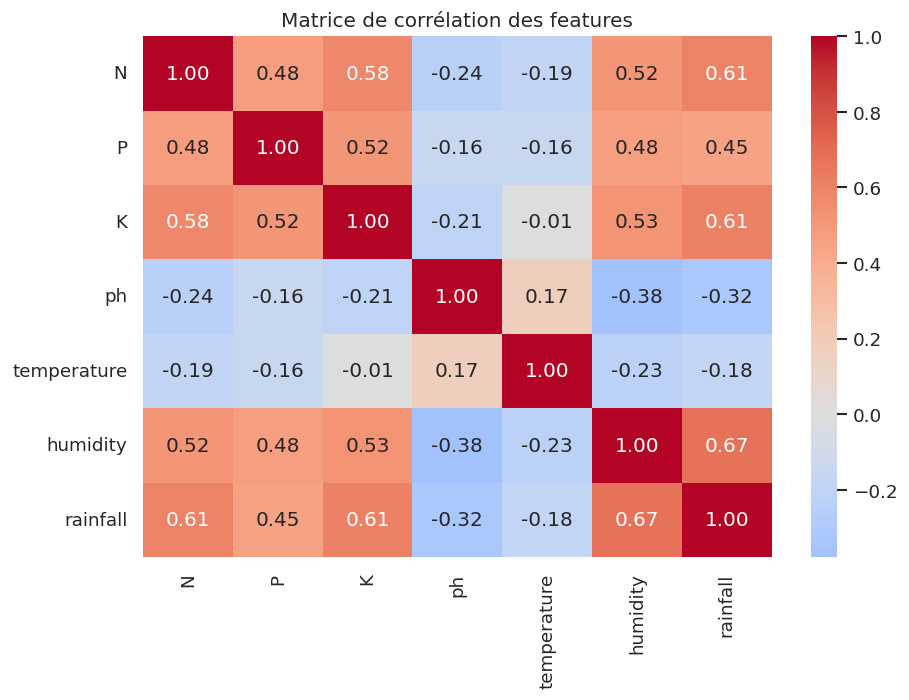

In [8]:
plt.figure(figsize=(8, 6))
corr = df[['N', 'P', 'K', 'ph', 'temperature', 'humidity', 'rainfall']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matrice de corrélation des features')
plt.tight_layout()
plt.show()

## 4. Sauvegarde du Dataset

In [9]:
output_path = 'data/research_based_dataset.csv'
df.to_csv(output_path, index=False)
print(f'✔ Dataset sauvegardé : {output_path}')
print(f'  Dimensions : {df.shape}')
print(f'  Cultures   : {df["label"].nunique()}')
print(f'  Unités N, P, K : mg/kg')

✔ Dataset sauvegardé : data/research_based_dataset.csv
  Dimensions : (7500, 8)
  Cultures   : 15
  Unités N, P, K : mg/kg


## 5. Tableau Récapitulatif des Intervalles Agronomiques (mg/kg)

In [10]:
rows = []
for crop, p in CROP_PARAMS.items():
    rows.append({
        'Culture': crop,
        'N mg/kg': f"{p['N'][0]}–{p['N'][1]}",
        'P mg/kg': f"{p['P'][0]}–{p['P'][1]}",
        'K mg/kg': f"{p['K'][0]}–{p['K'][1]}",
        'Temp. (°C)': f"{p['temperature'][0]}–{p['temperature'][1]}",
        'Humidité (%)': f"{p['humidity'][0]}–{p['humidity'][1]}",
        'pH': f"{p['ph'][0]}–{p['ph'][1]}",
        'Pluie (mm)': f"{p['rainfall'][0]}–{p['rainfall'][1]}",
        'Références': p['refs'],
    })

recap_df = pd.DataFrame(rows).set_index('Culture')
recap_df

,N mg/kg,P mg/kg,K mg/kg,Temp. (°C),Humidité (%),pH,Pluie (mm),Références
Culture,,,,,,,,
riz,60–120,15–35,20–50,22–32,70–90,5.0–7.0,1200–2500,[1][2]
mais,80–150,20–50,30–80,18–32,55–80,5.5–7.5,600–1200,[1][2][3]
sorgho,30–80,10–30,15–50,25–38,30–60,5.5–8.0,300–900,[1][2]
mil,20–70,5–25,10–40,25–40,25–55,5.5–8.5,200–700,[1][2]
haricot,20–60,15–40,20–60,18–28,50–75,5.5–7.0,400–900,[1][2][3]
soja,25–70,20–50,30–80,22–32,55–80,5.5–7.0,500–1100,[1][2]
niebe,15–50,10–35,15–55,24–36,35–70,5.5–7.5,300–1000,[1][2][3]
manioc,50–120,15–45,80–200,24–35,60–85,5.0–7.0,800–2000,[2][3][4]
igname,60–130,20–60,80–180,24–34,60–85,5.5–7.0,900–2000,[2][3]
